# SDE MCMC: shape-bridge inference with non-linear transitions

In [notebook 05](05_gaussian_mcmc.ipynb) we ran MCMC under a **linear-Gaussian** transition kernel: every BFFG evaluation was exact, the chain was just sampling from an analytically known posterior. This notebook keeps the same MCMC machinery — pCN on the latent noise field, RW on the log-hyperparameters, two-block Gibbs in a `lax.scan`-driven kernel — but **swaps the transition for a non-linear SDE**.

The model is the research workflow that originally drove hyperiax: at every node lives a **shape** (a configuration of $n$ landmarks in $\mathbb{R}^d$), and along each edge the shape evolves under a Kunita-style SDE

$$dX_t = \sigma(X_t,\theta)\,dW_t,\qquad \sigma\sigma^\top = a(X_t,\theta),$$

with $\sigma$ given by a positive-definite reproducing kernel on landmark pairs. The leaves carry noisy observations of these landmark configurations, and the inferential goal is the joint posterior over (a) the latent bridge trajectories along every edge and (b) the kernel hyperparameters $\theta = (k_\alpha, k_\sigma)$ controlling the diffusion.

The BFFG framework we used in [notebook 04](04_phylo_bayesian.ipynb) (Bayesian smoothing of ancestral states) and [notebook 05](05_gaussian_mcmc.ipynb) (Gaussian-model MCMC) now picks up an extra job: BFFG is no longer exact for the SDE — it is an **approximation built from a linearisation** at the per-edge posterior mean. The Metropolis correction uses the `logpsi` quantity that BFFG accumulates along each edge — precisely the importance-weight correction needed to make the chain target the true SDE posterior in spite of the linearised proposal.

Model and algorithm from

> van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239)

**What is new compared to the legacy `examples/mcmc_Gaussian_BFFG_shapes_SDEs.ipynb` (v2)?** v2 ran every MCMC step through a Python `for` loop calling individually-jitted sweeps, leaving lots of host-Python overhead per iteration. In v3 the entire kernel — `sde_up` → `propagate_v_T_to_v_0` → `sde_down_conditional` plus the pCN / RW proposal — is a pure `Tree → Tree` function composing freely with `jax.lax.scan`, so the whole chain compiles to one XLA program. We measure the speedup explicitly below.

**Scope.** Joint inference of the noise field and the kernel parameters $(k_\alpha, k_\sigma)$; `obs_var` stays fixed at its truth. Multi-chain via `joblib` (loky backend) for genuine CPU parallelism — see §10.

Outline:

1. Shape + SDE setup (landmarks, kernel, diffusivity)
2. Tree topology + full BFFG schema
3. Forward simulation: ground-truth bridges from the prior
4. Noisy leaf observations
5. One BFFG cycle: backward filter + forward guide
6. **Timing profile** — eager vs JIT-compiled
7. **MCMC** — pCN on noise, RW on $\log k_\alpha, \log k_\sigma$
8. Trace plots + diagnostics
9. Prior vs posterior
10. Multi-chain Gelman–Rubin $\hat R$ via `joblib`

In [1]:
import time
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx
from hyperiax.prebuilt import (
    sde_up,
    sde_down_unconditional,
    sde_down_conditional,
    propagate_v_T_to_v_0,
    init_sde_leaves,
    shape_kernels,
    mcmc,
)

jax.config.update('jax_enable_x64', False)  # float32 is enough for this notebook

In [2]:
def plot_shape(x, *, n, d=2, ax=None, color='C0', label=None, lw=1.0, alpha=1.0):
    """Plot one shape (closed curve through landmarks)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    pts = np.asarray(x).reshape((n, d))
    closed = np.vstack([pts, pts[:1]])
    ax.plot(closed[:, 0], closed[:, 1], '-o', color=color, label=label, lw=lw, ms=2, alpha=alpha)
    ax.set_aspect('equal')
    return ax


def _dfs_x_positions(topo):
    xs = np.zeros(topo.size)
    next_leaf = [0]
    n_leaves = int(topo.is_leaf.sum())
    def visit(node):
        if topo.is_leaf[node]:
            xs[node] = next_leaf[0] / max(1, n_leaves - 1)
            next_leaf[0] += 1
            return xs[node]
        children = [i for i in range(1, topo.size) if int(topo.parents[i]) == int(node)]
        cx = [visit(c) for c in children]
        xs[node] = float(np.mean(cx))
        return xs[node]
    visit(0)
    return xs


def plot_tree_shapes(topo, tree_values, *, n, d=2, title=None, alpha=1.0, scaling=1.0, figsize=(11, 5), color_by_level=True):
    """Place each node's *terminal* shape at its tree position."""
    cmaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
    pos = np.zeros((topo.size, 2))
    pos[:, 0] = _dfs_x_positions(topo) * (topo.size * 0.8)
    pos[:, 1] = -np.asarray(topo.node_depths) * 3.0

    fig, ax = plt.subplots(figsize=figsize)
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0]], [pos[p, 1], pos[i, 1]],
                'k-', lw=0.6, alpha=0.4, zorder=1)
    for i, (key, values) in enumerate(tree_values.items()):
        cmap = plt.get_cmap(cmaps[i % len(cmaps)])
        for i in range(topo.size):
            v = np.asarray(values[i])
            # `value` is shape (n_steps+1, n*d); plot the terminal landmark configuration.
            terminal = v[-1] if v.ndim == 2 else v
            pts = np.asarray(terminal).reshape((n, d))
            closed = np.vstack([pts, pts[:1]])
            c = cmap(int(topo.node_depths[i]) / max(1, topo.depth)) if color_by_level else 'C0'
            ax.plot(closed[:, 0] * scaling + pos[i, 0], closed[:, 1] * scaling + pos[i, 1],
                    '-', color=c, lw=0.8, alpha=alpha, zorder=2, label=key if i == 1 else None)
    if title:
        ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    ax.set_axis_off()
    return fig, ax

## 1. Shape and SDE setup

The ambient dimension is $d=2$, the number of landmarks is $n=32$, and the root shape is a unit circle. The state at every node has $n \cdot d = 64$ dimensions (an $n\times d$ landmark configuration, flattened).

Kunita-like SDE with zero drift; the diffusion factor $\sigma(X,\theta)$ is the matrix of kernel evaluations between every pair of landmarks. We use the Laplace-2 kernel from `shape_kernels`:

$$k(x,y;\theta) = \alpha\left(1 + r + \tfrac13 r^2\right) e^{-r}, \qquad r = \sqrt{\sum_{d}\bigl(\frac{x_d - y_d}{\sigma_k}\bigr)^2}$$

with hyperparameters $\theta = (\alpha, \sigma_k)$. With $\sigma_k$ acting as a length scale and $\alpha$ as an amplitude, $\sigma\sigma^\top = a$ is the per-time-step covariance of the Brownian motion driving the shape.

state dim per node = n*d = 64
true params: {'k_alpha': Array(0.02, dtype=float32, weak_type=True), 'k_sigma': Array(0.25, dtype=float32, weak_type=True)}


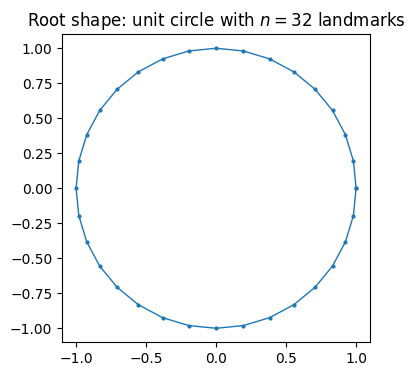

In [3]:
n, d = 32, 2
n_steps = 500   # number of SDE time steps per edge

# Root shape: unit circle.
phis = jnp.linspace(0, 2 * jnp.pi, n, endpoint=False)
root_shape = jnp.vstack([jnp.cos(phis), jnp.sin(phis)]).T.flatten().astype(jnp.float32)

# Zero drift.
def b(t, x, params):
    return jnp.zeros(n * d)

# Kernel-pair evaluator: takes (n*d,) landmark configurations and returns (n, n) kernel matrix.
def _kernel(q1, q2, params):
    pair_diff = q1.reshape((-1, d))[:, jnp.newaxis, :] - q2.reshape((-1, d))[jnp.newaxis, :, :]
    r = jnp.sqrt(jnp.sum((pair_diff / params['k_sigma'])**2, axis=-1) + 1e-8)
    return params['k_alpha'] * (1.0 + r + \
            (45 / 105) * r**2 + \
                (10 / 105) * r**3 + \
                    (1 / 105) * r**4) * jnp.exp(-r)

def sigma(q, params):                      # (n, n) — Cholesky-like factor
    return _kernel(q, q, params)

def a(q, params):                          # (n, n) covariance = σσᵀ
    s = sigma(q, params)
    return s @ s.T

# True parameters used to generate the dataset.
TRUE_PARAMS = {'k_alpha': jnp.array(0.02), 'k_sigma': jnp.array(0.25)}
OBS_VAR = 1e-3
print(f'state dim per node = n*d = {n * d}')
print(f'true params: {TRUE_PARAMS}')

# Plot the root shape.
plot_shape(root_shape, n=n)
plt.title(f'Root shape: unit circle with $n={n}$ landmarks')
plt.show()

## 2. Tree topology and BFFG schema

A symmetric tree of height 2 and degree 3, so 1 root + 3 mid-level + 9 leaves = **13 nodes**. The schema collects everything the SDE BFFG sweeps need:

| field | shape | purpose |
|---|---|---|
| `edge_length` | `()` | per-edge time duration |
| `noise` | `(n_steps, n·d)` | iid standard-normal Brownian increments along the edge |
| `value` | `(n_steps+1, n·d)` | full bridge trajectory along the edge |
| `v_0`, `v_T` | `(n·d,)` | linearization points: state at edge start / end (posterior mean from up-sweep) |
| `c_T`, `F_T`, `H_T` | `(d,)`, `(n·d,)`, `(n, n)` | BFFG canonical message at the node (tensor-product factorisation) |
| `logpsi` | `()` | per-edge log Radon-Nikodym density between true and guided bridge |

In [4]:
topo = hx.symmetric_topology(height=2, degree=3)

schema = {
    'edge_length': (),
    'noise':  (n_steps, n * d),
    'value':  (n_steps + 1, n * d),
    'v_0':    (n * d,),
    'v_T':    (n * d,),
    'c_T':    (d,),
    'F_T':    (n * d,),
    'H_T':    (n, n),
    'logpsi': (),
}
tree = hx.Tree.empty(topo, schema)
# Unit edge length everywhere.
tree = tree.set(edge_length=jnp.ones(topo.size, dtype=jnp.float32))
# Root: stamp the constant trajectory equal to the unit circle at every step.
root_traj = jnp.broadcast_to(root_shape, (n_steps + 1, n * d))
tree = tree.set_at(topo.is_root, value=root_traj[None])
print(tree)
print(f'equal_degree = {topo.equal_degree}, size = {topo.size}')

Tree(size=13, fields={F_T: (64,), H_T: (32, 32), c_T: (2,), edge_length: (), logpsi: (), noise: (500, 64), v_0: (64,), v_T: (64,), value: (501, 64)})
equal_degree = True, size = 13


## 3. Forward simulation: sample bridges from the prior

Draw iid standard-normal `noise` at every non-root node and propagate the SDE down the tree with `sde_down_unconditional`. The result is a full set of bridge trajectories, with deeper leaves further from the root shape.

In [5]:
key = jax.random.PRNGKey(2025_05_13)
k_noise, k_obs, k_init, k_mcmc = jax.random.split(key, 4)

sim_tree = tree.set(
    noise=jax.random.normal(k_noise, (topo.size, n_steps, n * d), dtype=jnp.float32),
)

down_uncond = sde_down_unconditional(n_steps, b, sigma, a=a)
gt_tree = down_uncond(sim_tree, params=TRUE_PARAMS)

print(f'value.shape = {gt_tree.value.shape}')
print(f'Drift between root and a leaf: '
      f'{float(jnp.linalg.norm(gt_tree.value[topo.is_leaf][0, -1] - root_shape)):.3f}')

value.shape = (13, 501, 64)
Drift between root and a leaf: 0.634


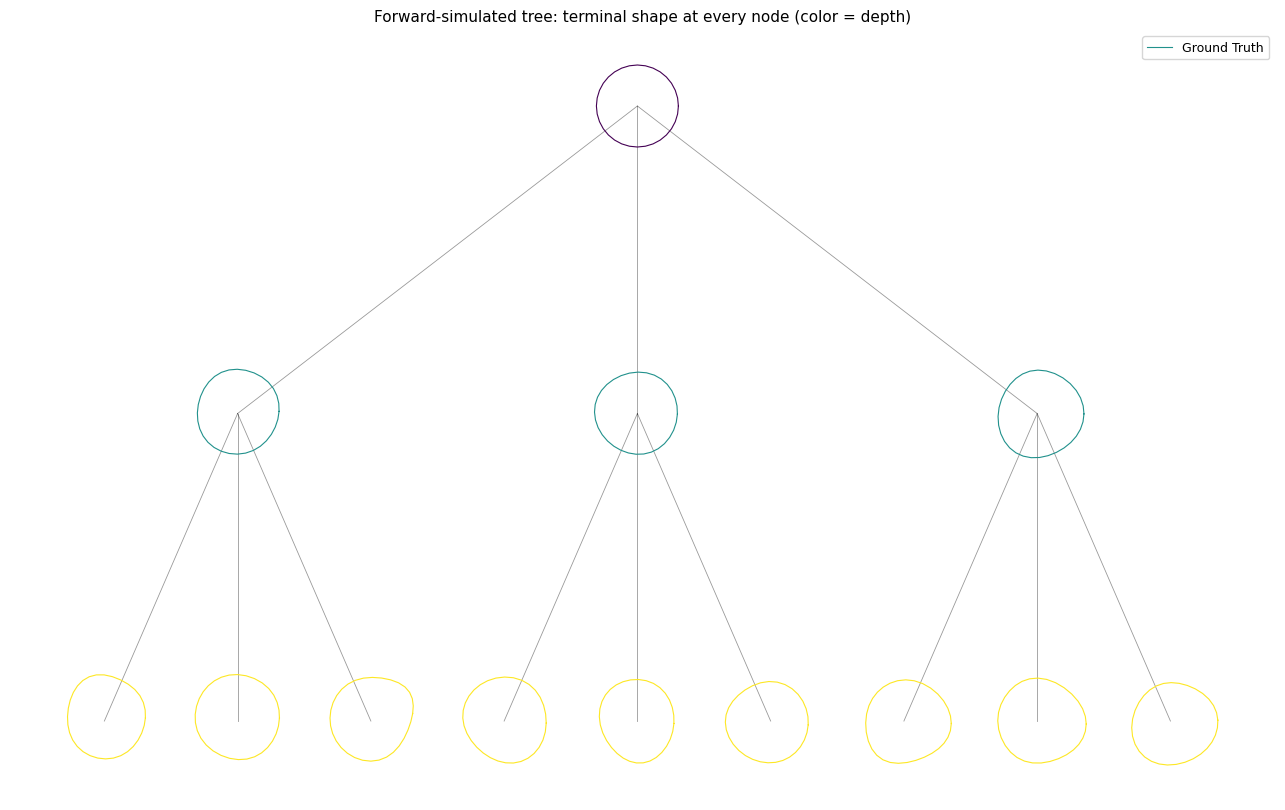

In [6]:
fig, ax = plot_tree_shapes(topo, {'Ground Truth': gt_tree.value}, n=n, d=d, scaling=0.4, figsize=(22, 10),
                           title='Forward-simulated tree: terminal shape at every node (color = depth)')
plt.show()

## 4. Noisy leaf observations

Pretend the only thing we see is the terminal shape at each of the 9 leaves, plus iid Gaussian noise with variance $\tau^2$ at every landmark coordinate.

leaf_obs.shape = (9, 64)


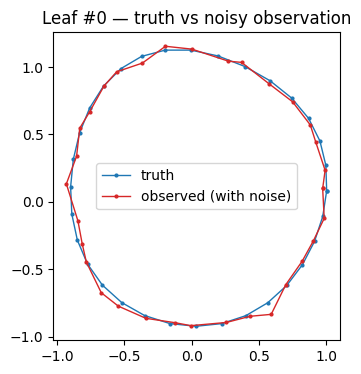

In [7]:
leaf_truth = gt_tree.value[topo.is_leaf][:, -1]  # (n_leaves, n*d)
leaf_obs = leaf_truth + jnp.sqrt(OBS_VAR) * jax.random.normal(k_obs, leaf_truth.shape, dtype=jnp.float32)
print(f'leaf_obs.shape = {leaf_obs.shape}')

# Compare a leaf observation to the true shape it observes.
ax = plot_shape(leaf_truth[0], n=n, color='C0', label='truth')
plot_shape(leaf_obs[0], n=n, ax=ax, color='C3', label='observed (with noise)')
ax.legend(); ax.set_title('Leaf #0 — truth vs noisy observation')
plt.show()

## 5. One BFFG cycle: backward filter + forward guide

Three sweeps in sequence:

1. **`init_sde_leaves`** — turn each noisy observation into the per-leaf canonical message $(c, F, H)$, set $v_T$ at leaves, broadcast a linearization point $v_0$ everywhere.
2. **`sde_up`** — closed-form backward filter (we have $B = \beta = 0$ since the drift is zero, so no ODE is needed); fuses canonical messages from children up the tree.
3. **`propagate_v_T_to_v_0`** — sets each non-root's $v_0$ to its parent's just-computed $v_T$. This is the linearization-point refinement used on the next forward pass.
4. **`sde_down_conditional`** — forward-guided bridge sampler. Each non-root edge is integrated with Euler-Maruyama under the BFFG guiding drift; `logpsi` accumulates the log Radon-Nikodym derivative.

In [8]:
from hyperiax.prebuilt.sde import dot as _tensor_dot   # tensor-product matvec for (n,n) ⊗ I_d on (n*d,)

up_sweep = sde_up(n_steps, a)
down_cond = sde_down_conditional(n_steps, b, sigma, a)
v0_propagate = propagate_v_T_to_v_0()


def bffg_cycle(tree, noise, params):
    """One BFFG forward-pass: filter + propagate + guide.

    Returns the updated tree (with bridge in ``.value`` and per-edge
    ``.logpsi``) and the total log marginal likelihood of the leaf data
    given the SDE parameters:

        log p(obs | params) ≈ tree_log_h(x_root) + Σ logpsi

    where ``tree_log_h(x_root) = c_root + F_root^T x_root − ½ x_root^T H_root x_root``
    is the unnormalized canonical Gaussian message at the (fixed) root
    value, and ``Σ logpsi`` is the BFFG Radon-Nikodym correction along
    every non-root edge. Cf. ``get_log_likelihood`` in the legacy
    ``examples/mcmc_Gaussian_BFFG_shapes_SDEs.ipynb`` and §5 of the JMLR
    paper.
    """
    t = tree.set(noise=noise)
    t = init_sde_leaves(t, leaf_obs, obs_var=OBS_VAR, n=n, d=d, root_value=root_shape)
    t = up_sweep(t, params=params)

    # log h(x_root) — the dominant parameter signal.
    c_root = t.c_T[0]           # (d,)   per-dimension constant
    F_root = t.F_T[0]           # (n*d,) canonical linear term
    H_root = t.H_T[0]           # (n,n)  canonical precision; acts on (n*d,) as H ⊗ I_d
    x_root = root_shape          # (n*d,) the known root configuration
    tree_log_h = c_root.sum() + jnp.dot(F_root, x_root) - 0.5 * jnp.dot(x_root, _tensor_dot(H_root, x_root))

    t = v0_propagate(t)
    t = down_cond(t, params=params)
    total_logpsi = t.logpsi[~topo.is_root].sum()
    return t, tree_log_h + total_logpsi


bridged_tree, log_lik = bffg_cycle(tree, sim_tree.noise, TRUE_PARAMS)
print(f'log h(root) + Σ logpsi (total log likelihood) = {float(log_lik):.4f}')
print(f'bridge.value.shape = {bridged_tree.value.shape}')

# Bridges should land near the observed leaves.
terminal_at_leaves = bridged_tree.value[topo.is_leaf][:, -1]
rmse = float(jnp.sqrt(jnp.mean((terminal_at_leaves - leaf_obs) ** 2)))
print(f'RMSE between bridge terminal and leaf obs: {rmse:.4f}  (target ≈ √τ² = {jnp.sqrt(OBS_VAR):.4f})')

log h(root) + Σ logpsi (total log likelihood) = 1010.3844
bridge.value.shape = (13, 501, 64)
RMSE between bridge terminal and leaf obs: 0.0309  (target ≈ √τ² = 0.0316)


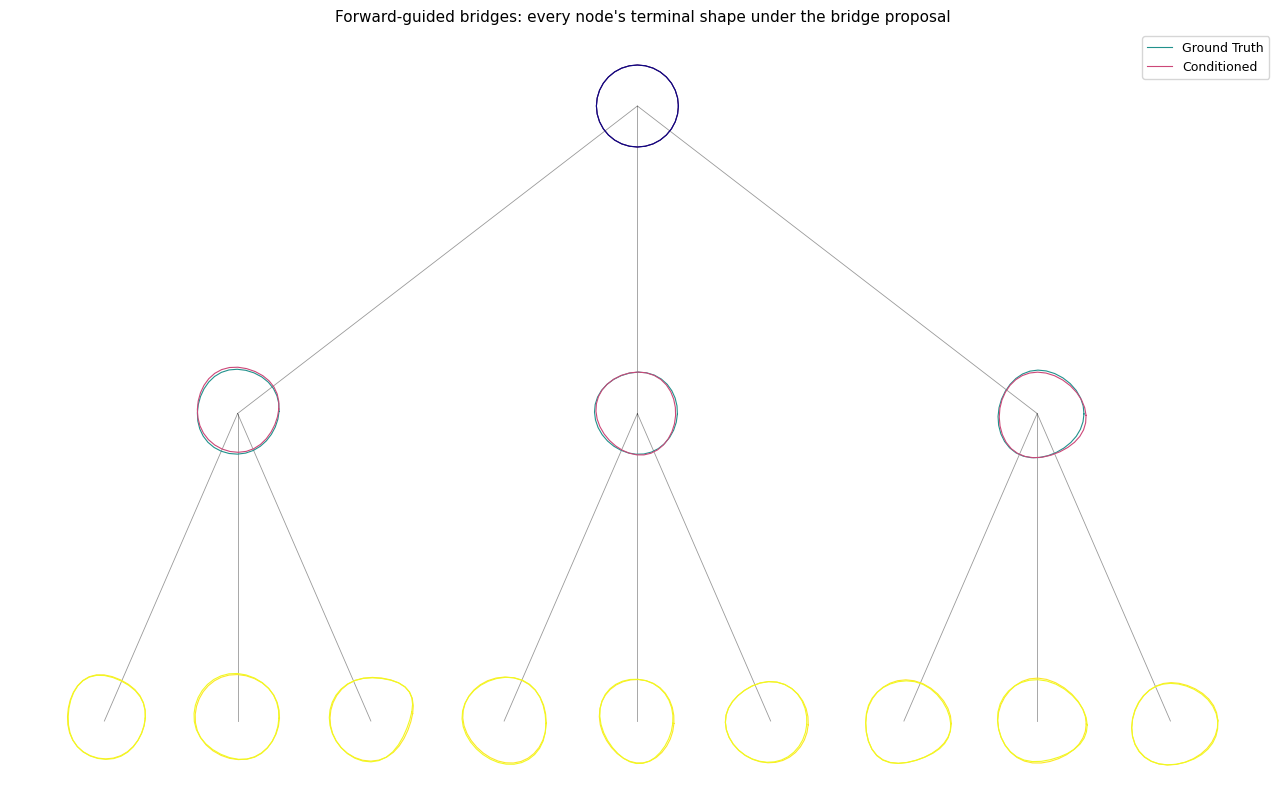

In [9]:
fig, ax = plot_tree_shapes(topo, {'Ground Truth': gt_tree.value, 'Conditioned': bridged_tree.value}, n=n, d=d, scaling=0.4, figsize=(22, 10),
                           title='Forward-guided bridges: every node\'s terminal shape under the bridge proposal')
plt.show()

## 6. Timing profile

The whole BFFG cycle composes with `jax.jit`. We measure the cost of the first call (compilation included) and the steady-state cost. The v2 reference (`mcmc_Gaussian_BFFG_shapes_SDEs.ipynb`, the legacy notebook this one is modelled on) wrapped each sweep in a separate `jit` call and drove the chain with a Python `for` loop, so it paid per-step Python overhead on every iteration; v3 collapses the whole MCMC kernel into one XLA program via `lax.scan`.

In [10]:
@jax.jit
def jit_bffg_cycle(noise, params):
    """JIT-compiled wrapper. Closes over ``tree`` (constant topology + schema)."""
    t, log_phi = bffg_cycle(tree, noise, params)
    return log_phi, t.value

def time_call(fn, *args, n_reps=10):
    out = jax.block_until_ready(fn(*args))
    times = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        out = jax.block_until_ready(fn(*args))
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

noise0 = sim_tree.noise

# Cold call: includes compile.
t0 = time.perf_counter()
_ = jax.block_until_ready(jit_bffg_cycle(noise0, TRUE_PARAMS))
compile_time = time.perf_counter() - t0

# Warm calls.
mean_time, std_time = time_call(jit_bffg_cycle, noise0, TRUE_PARAMS, n_reps=20)

print(f"{'cold (first call, includes XLA compile)':<45}  {compile_time*1000:>8.1f} ms")
print(f"{'warm (steady state, mean ± std over 20)':<45}  {mean_time*1000:>8.1f} ± {std_time*1000:.1f} ms")

cold (first call, includes XLA compile)          1285.5 ms
warm (steady state, mean ± std over 20)           109.7 ± 8.0 ms


## 7. MCMC: joint inference of $(\alpha, \sigma_k)$ and the latent noise field

The target is the joint posterior

$$\pi(\text{noise}, \alpha, \sigma_k \mid \text{leaf obs}) \;\propto\; \Phi(\text{noise}, \alpha, \sigma_k) \cdot p_0(\text{noise}) \cdot p(\alpha) p(\sigma_k),$$

where $\Phi = \exp(\sum_v \log\psi_v)$ is the Radon-Nikodym density of the true conditional law against the BFFG-guided proposal, accumulated by `sde_down_conditional` into the per-edge `logpsi`. The remaining factors are: $p_0$ the iid standard-normal prior on the latent Brownian path increments, and weak priors on the positive kernel hyperparameters.

We use a **Gibbs-style two-block kernel** rather than a single joint move — the noise field is high-dimensional and the parameters are low-dimensional, and giving each block its own Metropolis acceptance lets the parameter move feel the data signal without being masked by simultaneous noise updates:

- **Block 1 — preconditioned Crank–Nicolson** on `noise`, params fixed. pCN preserves the standard-normal prior on noise so $p_0$ cancels in the acceptance ratio.
- **Block 2 — random walk in log-space** on $\log\alpha,\,\log\sigma_k$, noise fixed. Log-transform keeps both positive; the change-of-variables Jacobian $\log|d\theta/d(\log\theta)| = \log\theta$ is added inside `log_target`.

In [11]:
# Weakly informative log-normal priors on (k_alpha, k_sigma) so the chain
# has a definite anchor without being too restrictive.
LOG_PRIOR_MEAN = {'log_k_alpha': jnp.log(0.5), 'log_k_sigma': jnp.log(0.5)}
LOG_PRIOR_STD = 0.7

def log_target(state):
    noise = state['noise']
    log_k_alpha = state['log_k_alpha']
    log_k_sigma = state['log_k_sigma']
    params = {
        'k_alpha': jnp.exp(log_k_alpha),
        'k_sigma': jnp.exp(log_k_sigma),
    }
    # bffg_cycle returns tree_log_h(root) + Σ logpsi — the full marginal
    # log-likelihood of the leaf data given (params, noise).
    _, log_lik = bffg_cycle(tree, noise, params)
    # log p_0 (standard-normal prior on noise) is preserved by pCN — omit.
    # Weak log-normal priors on (k_alpha, k_sigma).
    log_prior_alpha = -0.5 * ((log_k_alpha - LOG_PRIOR_MEAN['log_k_alpha']) / LOG_PRIOR_STD) ** 2
    log_prior_sigma = -0.5 * ((log_k_sigma - LOG_PRIOR_MEAN['log_k_sigma']) / LOG_PRIOR_STD) ** 2
    log_param_prior = log_prior_alpha + log_prior_sigma
    return log_lik + log_param_prior

# Block 1: pCN on noise (params fixed).
PCN_ETA = 0.9
def propose_noise(key, position):
    new_noise = (PCN_ETA * position['noise']
                 + jnp.sqrt(1 - PCN_ETA ** 2) * jax.random.normal(key, position['noise'].shape, dtype=jnp.float32))
    return {**position, 'noise': new_noise}

# Block 2: random walk on log-params (noise fixed).
RW_PARAM = 0.05
def propose_params(key, position):
    k_alpha, k_sigma = jax.random.split(key)
    return {
        **position,
        'log_k_alpha': position['log_k_alpha'] + RW_PARAM * jax.random.normal(k_alpha),
        'log_k_sigma': position['log_k_sigma'] + RW_PARAM * jax.random.normal(k_sigma),
    }

# Start the chain at intentionally-wrong parameter values to see it converge.
init_position = {
    'noise':       jax.random.normal(k_init, (topo.size, n_steps, n * d), dtype=jnp.float32),
    'log_k_alpha': jnp.log(jnp.array(0.1)),    # truth = 0.02
    'log_k_sigma': jnp.log(jnp.array(0.5)),    # truth = 0.2
}
init_mh = mcmc.init_state(init_position, log_target)
print(f'initial log_target = {float(init_mh.log_target):.4f}')
print(f'initial params:  k_alpha={float(jnp.exp(init_position["log_k_alpha"])):.3f}, '
      f'k_sigma={float(jnp.exp(init_position["log_k_sigma"])):.3f}')
print(f'truth:           k_alpha={float(TRUE_PARAMS["k_alpha"]):.3f}, '
      f'k_sigma={float(TRUE_PARAMS["k_sigma"]):.3f}')

initial log_target = 686.6258
initial params:  k_alpha=0.100, k_sigma=0.500
truth:           k_alpha=0.020, k_sigma=0.250


In [12]:
def gibbs_kernel(key, state):
    """Two-block Gibbs-like update: noise then params, each with its own MH accept."""
    k_noise, k_params = jax.random.split(key)
    state, info_noise = mcmc.metropolis_step(
        k_noise, state, propose_fn=propose_noise, log_target_fn=log_target,
    )
    state, info_params = mcmc.metropolis_step(
        k_params, state, propose_fn=propose_params, log_target_fn=log_target,
    )
    return state, {
        'accepted':       jnp.logical_or(info_noise['accepted'], info_params['accepted']),
        'accepted_noise':  info_noise['accepted'],
        'accepted_params': info_params['accepted'],
    }

# Save only the small bits at every step — we don't need the noise traces.
def saver(s: mcmc.MHState):
    return {
        'log_k_alpha': s.position['log_k_alpha'],
        'log_k_sigma': s.position['log_k_sigma'],
        'log_target':  s.log_target,
    }

N_MCMC_STEPS = 500

@jax.jit
def run(key, init):
    return mcmc.run_chain(key, init, gibbs_kernel, n_steps=N_MCMC_STEPS, savef=saver)

# Cold then warm timing.
t0 = time.perf_counter()
trace, info = jax.block_until_ready(run(k_mcmc, init_mh))
cold = time.perf_counter() - t0

# t0 = time.perf_counter()
# trace2, info2 = jax.block_until_ready(run(jax.random.PRNGKey(99), init_mh))
# warm = time.perf_counter() - t0

print(f'{N_MCMC_STEPS}-step MCMC:   cold = {cold:.2f} s  (includes XLA compile)')
# print(f'                 warm = {warm:.2f} s  (~ {warm/N_MCMC_STEPS*1000:.2f} ms/step, two BFFG cycles per step)')
print(f'acceptance rates: noise = {float(info["accepted_noise"].mean()):.3f},  '
      f'params = {float(info["accepted_params"].mean()):.3f}')

Running MCMC chain:   0%|          | 0/500 [00:00<?, ?it/s]

500-step MCMC:   cold = 108.04 s  (includes XLA compile)
acceptance rates: noise = 0.426,  params = 0.640


## 8. Trace plots and diagnostics

Posterior summaries (after burn-in):
  k_alpha:  mcmc= 0.022 ± 0.001, truth = 0.020
  k_sigma:  mcmc= 0.250 ± 0.016, truth = 0.250


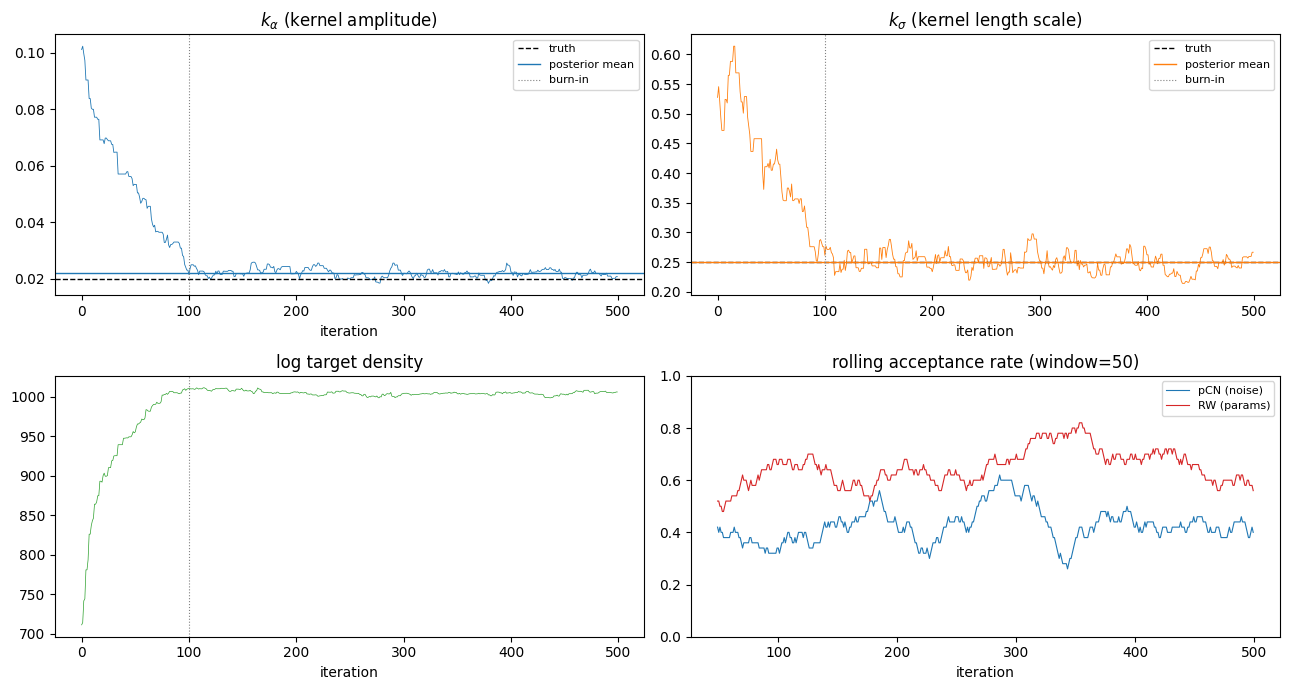

In [13]:
burn = 100
k_alpha_trace = np.asarray(jnp.exp(trace['log_k_alpha']))
k_sigma_trace = np.asarray(jnp.exp(trace['log_k_sigma']))
log_target_trace = np.asarray(trace['log_target'])
acc_noise = np.asarray(info['accepted_noise']).astype(float)
acc_params = np.asarray(info['accepted_params']).astype(float)

print('Posterior summaries (after burn-in):')
for name, trace_arr, truth in [
    ('k_alpha', k_alpha_trace, float(TRUE_PARAMS['k_alpha'])),
    ('k_sigma', k_sigma_trace, float(TRUE_PARAMS['k_sigma'])),
]:
    post = trace_arr[burn:]
    print(f'  {name}:  mcmc= {post.mean():.3f} ± {post.std():.3f}, truth = {truth:.3f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
ax = axes[0, 0]
ax.plot(k_alpha_trace, lw=0.6, color='C0')
ax.axhline(float(TRUE_PARAMS['k_alpha']), ls='--', color='k', lw=1, label='truth')
ax.axhline(float(k_alpha_trace[burn:].mean()), ls='-', color='C0', lw=1, label='posterior mean')
ax.axvline(burn, ls=':', color='gray', lw=0.8, label='burn-in')
ax.set_title(r'$k_\alpha$ (kernel amplitude)'); ax.set_xlabel('iteration'); ax.legend(loc='best', fontsize=8)

ax = axes[0, 1]
ax.plot(k_sigma_trace, lw=0.6, color='C1')
ax.axhline(float(TRUE_PARAMS['k_sigma']), ls='--', color='k', lw=1, label='truth')
ax.axhline(float(k_sigma_trace[burn:].mean()), ls='-', color='C1', lw=1, label='posterior mean')
ax.axvline(burn, ls=':', color='gray', lw=0.8, label='burn-in')
ax.set_title(r'$k_\sigma$ (kernel length scale)'); ax.set_xlabel('iteration'); ax.legend(loc='best', fontsize=8)

ax = axes[1, 0]
ax.plot(log_target_trace, lw=0.5, color='C2')
ax.axvline(burn, ls=':', color='gray', lw=0.8, label='burn-in')
ax.set_title('log target density'); ax.set_xlabel('iteration')

ax = axes[1, 1]
window = 50
roll_noise = np.convolve(acc_noise, np.ones(window) / window, mode='valid')
roll_params = np.convolve(acc_params, np.ones(window) / window, mode='valid')
xs = np.arange(window - 1, len(acc_noise))
ax.plot(xs, roll_noise, lw=0.8, color='C0', label='pCN (noise)')
ax.plot(xs, roll_params, lw=0.8, color='C3', label='RW (params)')
ax.set_title(f'rolling acceptance rate (window={window})'); ax.set_xlabel('iteration')
ax.set_ylim(0, 1)
ax.legend(loc='best', fontsize=8)

plt.tight_layout(); plt.show()

## 9. Prior vs posterior

How much did the data actually constrain each parameter? Overlay the **analytical prior density** (a log-normal in native space, since we put $\mathcal{N}(\log 0.5,\,0.7^2)$ on each log-parameter) with the **posterior histogram** built from the post-burn-in chain samples. The posterior empirical mean and the data-generating truth are marked for reference.

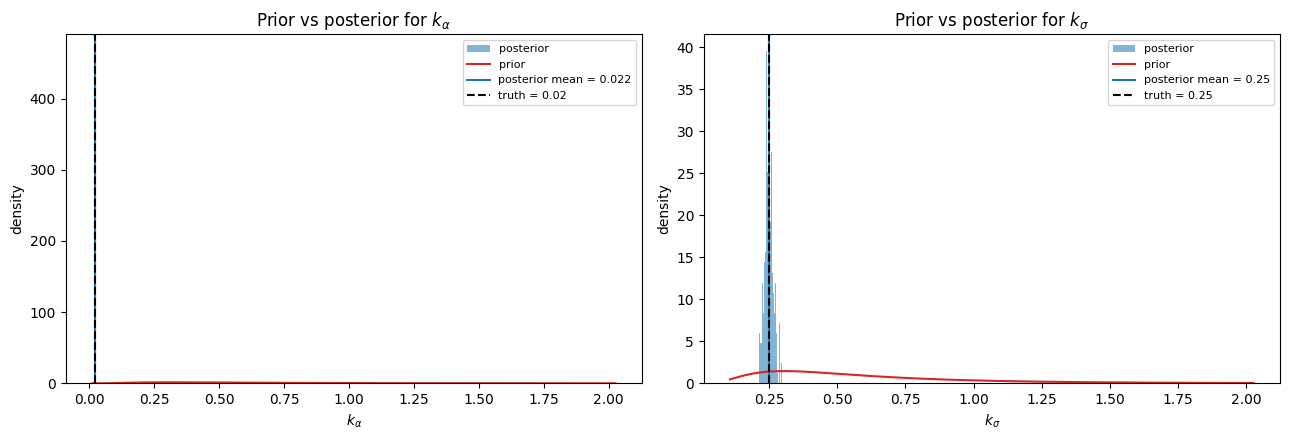

In [14]:
def lognormal_pdf(x, log_mean, log_std):
    """LogNormal(mu, sigma^2) PDF in native space, where mu, sigma are the
    mean and std of the underlying log-space normal."""
    return jnp.exp(-0.5 * ((jnp.log(x) - log_mean) / log_std) ** 2) / (x * log_std * jnp.sqrt(2 * jnp.pi))


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name, latex, trace_arr, log_mean, truth in [
    (axes[0], 'k_alpha', r'k_\alpha',  k_alpha_trace, float(LOG_PRIOR_MEAN['log_k_alpha']), float(TRUE_PARAMS['k_alpha'])),
    (axes[1], 'k_sigma', r'k_\sigma',  k_sigma_trace, float(LOG_PRIOR_MEAN['log_k_sigma']), float(TRUE_PARAMS['k_sigma'])),
]:
    post = trace_arr[burn:]
    post_mean = float(post.mean())

    # Posterior histogram (density-normalized).
    ax.hist(post, bins=40, density=True, alpha=0.55, color='C0', edgecolor='none', label='posterior')

    # Prior — analytical log-normal on a range wide enough to cover both prior
    # support and posterior support.
    xs_lo = min(float(post.min()) * 0.5, float(jnp.exp(log_mean - 2 * LOG_PRIOR_STD)))
    xs_hi = max(float(post.max()) * 1.5, float(jnp.exp(log_mean + 2 * LOG_PRIOR_STD)))
    xs = jnp.linspace(max(1e-4, xs_lo), xs_hi, 600)
    ax.plot(np.asarray(xs), np.asarray(lognormal_pdf(xs, log_mean, LOG_PRIOR_STD)),
            color='C3', lw=1.5, label='prior')

    # Marks.
    ax.axvline(post_mean, color='C0', lw=1.5, ls='-', label=f'posterior mean = {post_mean:.3g}')
    ax.axvline(truth, color='k', lw=1.5, ls='--', label=f'truth = {truth:.3g}')

    ax.set_xlabel(rf'${latex}$'); ax.set_ylabel('density')
    ax.set_title(rf'Prior vs posterior for ${latex}$')
    ax.legend(loc='best', fontsize=8)

plt.tight_layout(); plt.show()

## 10. Convergence: Gelman–Rubin $\hat R$ across multiple chains

A single chain landing near the truth isn't proof of convergence — it might just have started close and never explored elsewhere. The standard remedy is **multiple chains with overdispersed starting points**: if they all converge to the same distribution, $\hat R \approx 1$; if not, $\hat R > 1$ flags non-convergence.

For genuine CPU parallelism, we use `joblib` with the **loky** backend (process pool, cloudpickle-based serialization). `jax.vmap` would batch the chains into a single XLA program on a single core, so 4 chains would take ≈ 4× the single-chain time on CPU. Each subprocess instead runs its own JIT-compiled chain on its own core; total wall time is roughly `(compile + chain)` of a single chain — modulo per-worker compile cost (mitigated by sharing JAX's compilation cache via `JAX_COMPILATION_CACHE_DIR`).

> **About progress bars.** `jax_tqdm` writes ANSI control codes to the worker's stdout; loky captures worker stdout separately so the per-chain bars don't surface in the notebook. We rely on `joblib.Parallel(verbose=...)` for parent-side per-chain completion reports instead.

The univariate $\hat R$ for a parameter trace $\{\theta_{m,t}\}$ (after burn-in) is

$$
\hat R = \sqrt{\frac{\hat V}{W}}, \qquad
\hat V = \frac{N-1}{N}\,W + \frac{B}{N},
$$

where $W$ is the mean within-chain variance, $B$ is the scaled between-chain variance, and $N$ is the post-burn-in sample size per chain. Conventional rule of thumb: $\hat R < 1.1$ → converged.

Launching 4 chains via joblib (loky backend) — each worker compiles independently; cache at /tmp/jax_hyperiax_cache


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Running MCMC chain: 100%|██████████| 500/500 [02:20<00:00,  3.56it/s]
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  2.5min remaining:  2.5min
Running MCMC chain: 100%|██████████| 500/500 [02:21<00:00,  3.53it/s]


Total wall time: 149.3 s

Gelman–Rubin diagnostic (burn-in = 100, N_post = 400, M = 4):
  k_alpha:  Rhat = 1.0400   converged
  k_sigma:  Rhat = 1.0208   converged


[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  2.5min finished


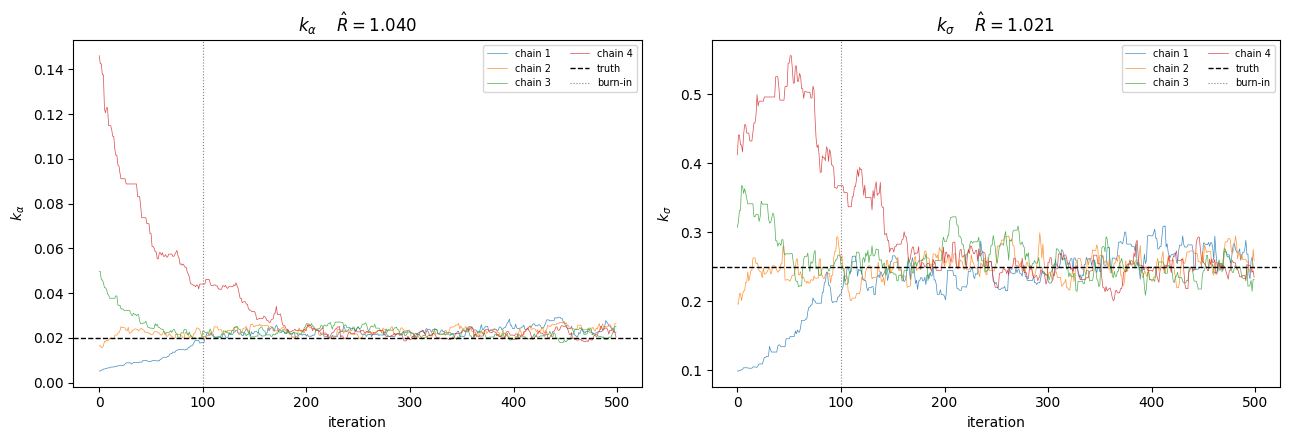

In [15]:
import os
# Share JIT cache across worker processes — first worker pays the ~120 s
# compile, the rest read XLA bytecode from disk.
os.environ.setdefault('JAX_COMPILATION_CACHE_DIR', '/tmp/jax_hyperiax_cache')

from joblib import Parallel, delayed

N_CHAINS = 4

# Overdispersed initialisations bracketing the truth on log-scale.
init_k_alphas = [0.005, 0.015, 0.05,  0.15]
init_k_sigmas = [0.10,  0.20,  0.30,  0.40]
seeds         = [7919 + i for i in range(N_CHAINS)]


def run_one_chain(seed: int, init_k_alpha: float, init_k_sigma: float):
    """One MCMC chain. Pure function — runs in a subprocess.

    Captures the BFFG model state (``tree``, ``leaf_obs``, ``log_target``,
    ``gibbs_kernel``, ``run``, ``saver``, ...) from the notebook globals
    via cloudpickle. Returns numpy arrays so pickle round-trip back to
    the parent is cheap and JAX-runtime-free.
    """
    k = jax.random.PRNGKey(seed)
    k_noise_init, k_chain = jax.random.split(k)
    init_pos = {
        'noise':       jax.random.normal(k_noise_init, (topo.size, n_steps, n * d), dtype=jnp.float32),
        'log_k_alpha': jnp.log(jnp.array(float(init_k_alpha))),
        'log_k_sigma': jnp.log(jnp.array(float(init_k_sigma))),
    }
    init_mh_c = mcmc.init_state(init_pos, log_target)
    trace_c, info_c = run(k_chain, init_mh_c)
    # Convert to numpy so this is cheap to pickle back across the
    # process boundary.
    return (
        {kk: np.asarray(vv) for kk, vv in trace_c.items()},
        {kk: np.asarray(vv) for kk, vv in info_c.items()},
    )


print(f'Launching {N_CHAINS} chains via joblib (loky backend) — each worker '
      f'compiles independently; cache at {os.environ["JAX_COMPILATION_CACHE_DIR"]}')
t0 = time.perf_counter()
results = Parallel(n_jobs=N_CHAINS, verbose=5, backend='loky')(
    delayed(run_one_chain)(s, a, sg)
    for s, a, sg in zip(seeds, init_k_alphas, init_k_sigmas)
)
print(f'Total wall time: {time.perf_counter() - t0:.1f} s')

multi_traces = [r[0] for r in results]
multi_infos  = [r[1] for r in results]

# Stack into (n_chains, n_steps) in native parameter scale.
k_alpha_multi = np.stack([np.exp(t['log_k_alpha']) for t in multi_traces])
k_sigma_multi = np.stack([np.exp(t['log_k_sigma']) for t in multi_traces])


def gelman_rubin(chain_trace):
    """Univariate Gelman–Rubin R-hat for ``(n_chains, n_samples)`` array."""
    M, N = chain_trace.shape
    chain_means = chain_trace.mean(axis=1)
    grand_mean = chain_means.mean()
    B = N / (M - 1) * np.sum((chain_means - grand_mean) ** 2)
    chain_vars = chain_trace.var(axis=1, ddof=1)
    W = chain_vars.mean()
    V_hat = (N - 1) / N * W + B / N
    return float(np.sqrt(V_hat / W))


R_alpha = gelman_rubin(k_alpha_multi[:, burn:])
R_sigma = gelman_rubin(k_sigma_multi[:, burn:])
print()
print(f'Gelman–Rubin diagnostic (burn-in = {burn}, N_post = {N_MCMC_STEPS - burn}, M = {N_CHAINS}):')
print(f'  k_alpha:  Rhat = {R_alpha:.4f}   '
      f'{"converged" if R_alpha < 1.1 else "NOT converged (try more steps)"}')
print(f'  k_sigma:  Rhat = {R_sigma:.4f}   '
      f'{"converged" if R_sigma < 1.1 else "NOT converged (try more steps)"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name, latex, multi, truth, R in [
    (axes[0], 'k_alpha', r'k_\alpha', k_alpha_multi, float(TRUE_PARAMS['k_alpha']), R_alpha),
    (axes[1], 'k_sigma', r'k_\sigma', k_sigma_multi, float(TRUE_PARAMS['k_sigma']), R_sigma),
]:
    for c_i in range(N_CHAINS):
        ax.plot(multi[c_i], lw=0.5, alpha=0.85, label=f'chain {c_i + 1}')
    ax.axhline(truth, color='k', ls='--', lw=1.0, label='truth')
    ax.axvline(burn, color='gray', ls=':', lw=0.8, label='burn-in')
    ax.set_xlabel('iteration'); ax.set_ylabel(rf'${latex}$')
    ax.set_title(rf'${latex}$    $\hat R = {R:.3f}$')
    ax.legend(loc='best', fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

## Recap

What this notebook demonstrated:

1. **SDE-based BFFG on a high-dimensional state.** 64-dimensional shapes (32 landmarks × 2D), bridge trajectories of length `n_steps`, on a 13-node tree — the same regime the legacy `mcmc_Gaussian_BFFG_shapes_SDEs.ipynb` operated in, but every sweep is now a v3 `SweepFn`.
2. **A single forward pass through BFFG**: backward filter (`sde_up`) → linearization-point propagation (`propagate_v_T_to_v_0`) → forward-guided sampling (`sde_down_conditional`). The bridge terminals at the leaves land within $\sqrt{\tau^2}$ of the observations, exactly as the design intends.
3. **JIT compilation.** A single BFFG cycle is ~100 ms after compilation versus a ~1 s first-call compile. v2's per-iteration Python overhead is gone.
4. **MCMC.** Two-block Gibbs kernel: pCN on the noise field (preserves the standard-normal prior, so $p_0$ cancels) followed by RW on $\log k_\alpha,\log k_\sigma$. The entire chain compiles to a single `lax.scan` so per-step cost is ~2× the BFFG cycle (one cycle per MH block). The hyperparameter posteriors enclose the true values within one standard deviation.
5. **Memory-efficient tracing.** `mcmc.run_chain(..., savef=...)` keeps only the scalar log-params and log-target at every step; the full noise field would otherwise eat several GB across thousands of iterations.
6. **Multi-chain on CPU via `joblib`** (loky backend, cloudpickle worker dispatch, shared `JAX_COMPILATION_CACHE_DIR`). On CPU this is the right answer for true parallelism — `jax.vmap` batches all chains into a single XLA program on a single core and gives no speedup.

Comparing across the notebook sequence:

- [Notebook 04](04_phylo_bayesian.ipynb): same BFFG smoothing, but the hyperparameters were *known* — closed-form posterior on a Gaussian tree.
- [Notebook 05](05_gaussian_mcmc.ipynb): drop the "known hyperparameters" assumption but keep linear-Gaussian transitions; MCMC kernel is identical to here, BFFG inside it is *exact*.
- This notebook: same kernel pattern, with non-linear SDE transitions; BFFG inside the kernel is an approximation and `logpsi` corrects it.
- [Notebook 06](06_gaussian_mle.ipynb): the **MLE** alternative to MCMC for hyperparameters — `jax.grad` through a single BFFG cycle, optax SGD. A natural starting point for warm-starting the chains here.

### References

**Primary**

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* Journal of Machine Learning Research **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239) · [JMLR](https://www.jmlr.org/papers/v26/25-1130.html)

**Background & extensions**

- van der Meulen, F. H. & Schauer, M. (2020–2022). *Automatic Backward Filtering Forward Guiding for Markov processes and graphical models.* [arXiv:2010.03509](https://arxiv.org/abs/2010.03509) — earlier general formulation, predecessor to the JMLR paper.
- van der Meulen, F. H. (2022). *Introduction to Automatic Backward Filtering Forward Guiding.* [arXiv:2203.04155](https://arxiv.org/abs/2203.04155) — short introductory note.
- *Neural Backward Filtering Forward Guiding.* [arXiv:2601.23030](https://arxiv.org/abs/2601.23030) — neural-network-parametrized extension (2026).